##### Copyright 2018 The TensorFlow Authors.

In [1]:
import os
import json
import zipfile
import pandas as pd

!pip install -q kaggle

kaggle_api_key = {
    "username": "yehhsiangchen",
    "key": "76c2c7fff5caf4938e096ffd2026fe7e"
}

os.makedirs(os.path.expanduser("~/.kaggle/"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_api_key, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

competition_name = "histopathologic-cancer-detection"
data_dir = "./kaggle_data"
os.makedirs(data_dir, exist_ok=True)

!kaggle competitions download -c {competition_name} -p {data_dir}

for file in os.listdir(data_dir):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(data_dir, file), "r") as zip_ref:
            zip_ref.extractall(data_dir)

labels_file = os.path.join(data_dir, "train_labels.csv")
if os.path.exists(labels_file):
    labels = pd.read_csv(labels_file)
    print(f"標籤數據集已加載，總數據量: {len(labels)}")
    print(labels.head())
else:
    print("標籤文件未找到！")

for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


Streaming output truncated to the last 5000 lines.
        81b16648b58887b4ff3383bf1f3eb77f59c587b2.tif
        a7488983798cc5a531f6be455372cc10a0e2ff98.tif
        f69290c1fee582c5bb3fa336a6ceb45687481df7.tif
        2a13abee522a4825410e76ba30f1ff6e25372167.tif
        e9f7864ad5138c8de0049e948009e6a950562d89.tif
        e4b4fbd8fc73e9257991c27f766ee901a5be177a.tif
        d790e60b92114d99ba036d26ab18e77693336a4b.tif
        75ff2caf2b732517a4ab0865df47e3ee16748772.tif
        5b9139e857cd122d4a452163db698a42a27ff404.tif
        0e9e891fd560846ad21b4e861ac93ca138a4565b.tif
        6fec540be1ce2d58dc3086e73c9a8fde10e79381.tif
        1922df092004851884be59d718ee9e4169a552e5.tif
        e6905d9ce23ffcb85c8efe169c8a45a979410699.tif
        8f544e1ff9ab93163b70900ddf057ee4552be523.tif
        46f4c3627585d6dd64e73cf10ad0ccb2636aef3a.tif
        4531d36020cf08690fe845350d9630400b11be35.tif
        e07fc4f0f3853d11d2d1cbd841c4f62d31a1393a.tif
        f24b2f74676af387e75805b2e8cbc8175de16f78

histopathologic-cancer-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


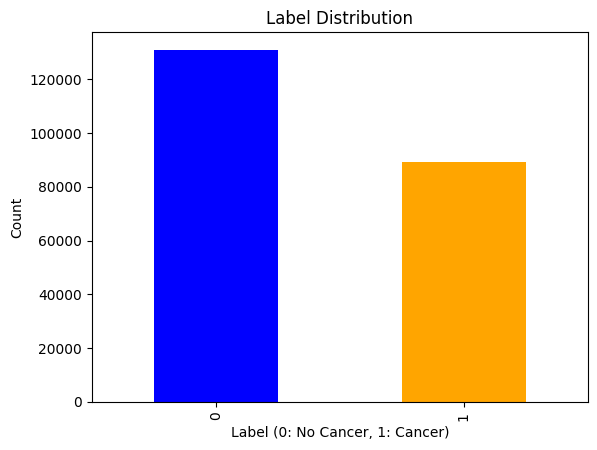

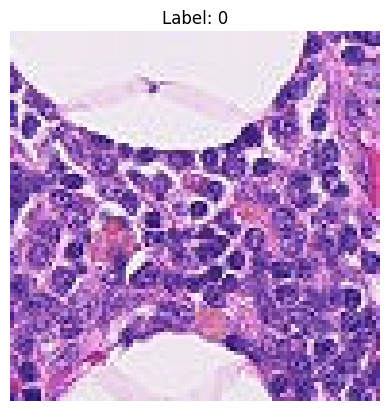

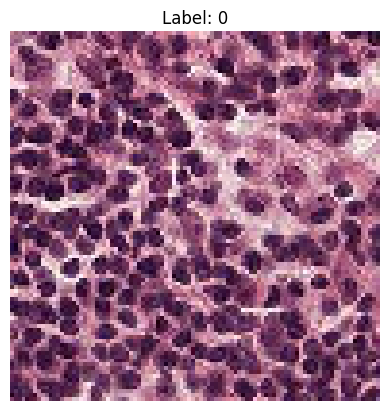

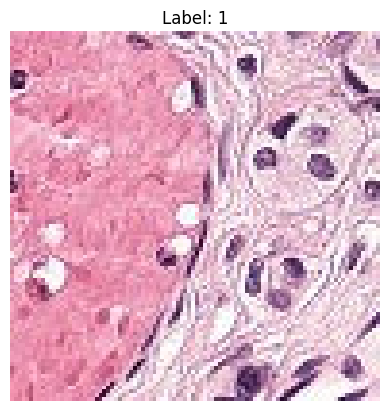

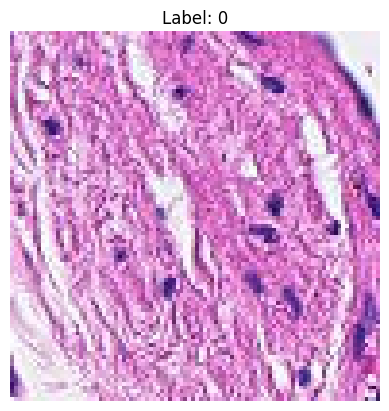

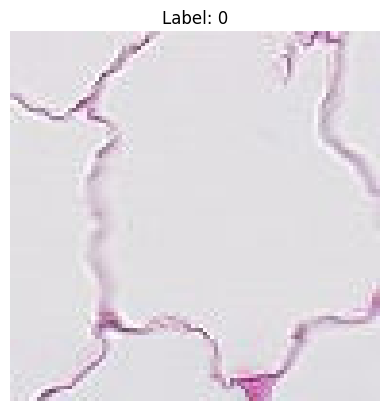

Found 176020 validated image filenames belonging to 2 classes.
Found 44005 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5501/5501 ━━━━━━━━━━━━━━━━━━━━ 852s 154ms/step - accuracy: 0.7549 - loss: 0.5081 - val_accuracy: 0.8154 - val_loss: 0.4183
Epoch 2/10
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 812s 148ms/step - accuracy: 0.8180 - loss: 0.4145 - val_accuracy: 0.8227 - val_loss: 0.4068
Epoch 3/10
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 781s 142ms/step - accuracy: 0.8274 - loss: 0.3940 - val_accuracy: 0.8356 - val_loss: 0.3712
Epoch 4/10
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 776s 141ms/step - accuracy: 0.8332 - loss: 0.3820 - val_accuracy: 0.8486 - val_loss: 0.3488
Epoch 5/10
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 796s 140ms/step - accuracy: 0.8393 - loss: 0.3732 - val_accuracy: 0.8357 - val_loss: 0.3696
Epoch 6/10
5174/5501 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.8390 - loss: 0.3704

In [ ]:
import os
import json
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import roc_auc_score, roc_curve

!pip install -q kaggle

kaggle_api_key = {
    "username": "yehhsiangchen",
    "key": "76c2c7fff5caf4938e096ffd2026fe7e"
}

os.makedirs(os.path.expanduser("~/.kaggle/"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_api_key, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

competition_name = "histopathologic-cancer-detection"
data_dir = "./kaggle_data"
os.makedirs(data_dir, exist_ok=True)

!kaggle competitions download -c {competition_name} -p {data_dir}

for file in os.listdir(data_dir):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(data_dir, file), "r") as zip_ref:
            zip_ref.extractall(data_dir)

labels_file = os.path.join(data_dir, "train_labels.csv")
labels = pd.read_csv(labels_file)

labels['id'] = labels['id'] + '.tif'
labels['label'] = labels['label'].astype(str)

label_counts = labels['label'].value_counts()
label_counts.plot(kind='bar', color=['blue', 'orange'], title='Label Distribution')
plt.xlabel('Label (0: No Cancer, 1: Cancer)')
plt.ylabel('Count')
plt.show()

image_folder = os.path.join(data_dir, 'train')
sample_images = labels.sample(5)
for idx, row in sample_images.iterrows():
    img_path = os.path.join(image_folder, row['id'])
    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Label: {row['label']}")
    plt.axis('off')
    plt.show()

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20
)

train_generator = datagen.flow_from_dataframe(
    dataframe=labels,
    directory=image_folder,
    x_col='id',
    y_col='label',
    subset='training',
    batch_size=32,
    class_mode='binary',
    target_size=(96, 96)
)

val_generator = datagen.flow_from_dataframe(
    dataframe=labels,
    directory=image_folder,
    x_col='id',
    y_col='label',
    subset='validation',
    batch_size=32,
    class_mode='binary',
    target_size=(96, 96)
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

val_preds = model.predict(val_generator)
val_labels = val_generator.classes
auc_score = roc_auc_score(val_labels, val_preds)
fpr, tpr, _ = roc_curve(val_labels, val_preds)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()



In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(96, 96, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



In [1]:
import os
import json


kaggle_api_key = {
    "username": "yehhsiangchen",
    "key": "76c2c7fff5caf4938e096ffd2026fe7e"
}


os.makedirs(os.path.expanduser("~/.kaggle/"), exist_ok=True)


with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_api_key, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

print("Kaggle API 配置完成！")





Kaggle API 配置完成！


In [2]:
!kaggle datasets list

ref                                                           title                                            size  lastUpdated          downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  ----------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
muhammadroshaanriaz/students-performance-dataset-cleaned      Students Performance | Clean Dataset             10KB  2024-10-29 19:32:26           9409        172  1.0              
steve1215rogg/student-lifestyle-dataset                       student lifestyle dataset                        22KB  2024-11-11 19:11:28           4425         65  1.0              
brsahan/vehicle-co2-emissions-dataset                         Vehicle CO2 Emissions Dataset                    88KB  2024-11-20 22:24:16            771         30  1.0              
jakewright/200k-youtube-channel-analytics                     200k YouTube Channel Analyti

In [3]:
!kaggle competitions download -c histopathologic-cancer-detection -p ./kaggle_data


100% 6.29G/6.31G [01:04<00:00, 188MB/s]
100% 6.31G/6.31G [01:04<00:00, 105MB/s]


In [4]:
import os
import zipfile

data_dir = "./kaggle_data"
os.makedirs(data_dir, exist_ok=True)

for file in os.listdir(data_dir):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(data_dir, file), "r") as zip_ref:
            zip_ref.extractall(data_dir)

for root, dirs, files in os.walk(data_dir):
    for file in files:
        print(os.path.join(root, file))


Streaming output truncated to the last 5000 lines.
./kaggle_data/train/1266b36a99780b0446ff80fb6e81e7db712785b5.tif
./kaggle_data/train/a84f847f36e69792748fee628a4deabebf67034a.tif
./kaggle_data/train/f8a12e6f15e6069c6a61bcdf9e9402e92570a51a.tif
./kaggle_data/train/aa5044a6843c8ccdc6440629c9bfedff5e8df4d3.tif
./kaggle_data/train/36f64448a7eb1310b48c5d26e6b28c411a1936fc.tif
./kaggle_data/train/9fb0ea38e7012b9a8e909972cbbaf2869c063189.tif
./kaggle_data/train/f6434ade2f5a192c3c60ff425527d8882f7d64f1.tif
./kaggle_data/train/69e090ccea3fbe680d7ee7e95382bcc4010e0152.tif
./kaggle_data/train/4da7d38e83f496e7e57f22f22f6912114fc14d3e.tif
./kaggle_data/train/0056b591aecd870591760b3964792c5b584e7cfa.tif
./kaggle_data/train/dd7954df7101fe4ab1e6f323edc811826313bb48.tif
./kaggle_data/train/12490dbe16b57b13d31b627b41ac409775ceffdb.tif
./kaggle_data/train/9b3e95c1550a9b843c9e83c7bf074722dc60da17.tif
./kaggle_data/train/d37d2761b166007ed360a5aee25b7cdc9f8ba999.tif
./kaggle_data/train/3496015145f60b8e4e1

In [5]:
import pandas as pd

labels_file = './kaggle_data/train_labels.csv'
labels = pd.read_csv(labels_file)


print(labels.head())


                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0


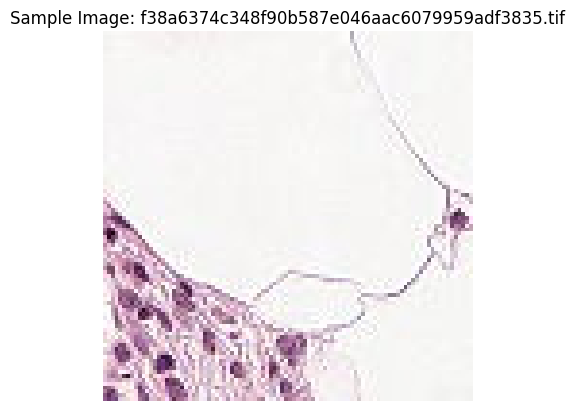

In [6]:
import cv2
import matplotlib.pyplot as plt

image_folder = './kaggle_data/train'
sample_image_id = labels.iloc[0]['id'] + '.tif'
sample_image_path = f"{image_folder}/{sample_image_id}"


image = cv2.imread(sample_image_path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(f"Sample Image: {sample_image_id}")
plt.axis('off')
plt.show()


In [9]:

print(labels['label'].dtype)


print(labels['label'].unique())



int64
[0 1]


In [10]:
labels['label'] = labels['label'].astype(str)


In [11]:

print(labels['label'].isnull().sum())

unexpected_values = labels[~labels['label'].isin(['0', '1'])]
print(unexpected_values)


0
Empty DataFrame
Columns: [id, label]
Index: []


In [12]:
import pandas as pd


labels_file = './kaggle_data/train_labels.csv'

import os
print("File exists:", os.path.exists(labels_file))


try:
    labels = pd.read_csv(labels_file)
    print(labels.head())
    print(labels.info())
except Exception as e:
    print("Error reading labels file:", e)


File exists: True
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB
None


In [13]:

print("Unique labels:", labels['label'].unique())


Unique labels: [0 1]


In [14]:
image_folder = './kaggle_data/train'


labels['exists'] = labels['id'].apply(lambda x: os.path.exists(os.path.join(image_folder, f"{x}.tif")))
print(labels['exists'].value_counts())


exists
True    220025
Name: count, dtype: int64


In [15]:
!kaggle competitions download -c histopathologic-cancer-detection -p ./kaggle_data


histopathologic-cancer-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [16]:
import zipfile

data_dir = "./kaggle_data"
for file in os.listdir(data_dir):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(data_dir, file), "r") as zip_ref:
            zip_ref.extractall(data_dir)


In [17]:
print(labels.head())
print(labels.info())


                                         id  label  exists
0  f38a6374c348f90b587e046aac6079959adf3835      0    True
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1    True
2  755db6279dae599ebb4d39a9123cce439965282d      0    True
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0    True
4  068aba587a4950175d04c680d38943fd488d6a9d      0    True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
 2   exists  220025 non-null  bool  
dtypes: bool(1), int64(1), object(1)
memory usage: 3.6+ MB
None


In [18]:

labels['label'] = labels['label'].astype(str)


print(labels.dtypes)


id        object
label     object
exists      bool
dtype: object


In [21]:

labels['id'] = labels['id'].apply(lambda x: f"{x}.tif")


labels = labels.dropna(subset=['id', 'label'])

image_folder = './kaggle_data/train'

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20
)

train_generator = datagen.flow_from_dataframe(
    dataframe=labels,
    directory=image_folder,
    x_col='id',
    y_col='label',
    subset='training',
    batch_size=32,
    class_mode='binary',
    target_size=(96, 96)
)

val_generator = datagen.flow_from_dataframe(
    dataframe=labels,
    directory=image_folder,
    x_col='id',
    y_col='label',
    subset='validation',
    batch_size=32,
    class_mode='binary',
    target_size=(96, 96)
)


Found 176020 validated image filenames belonging to 2 classes.
Found 44005 validated image filenames belonging to 2 classes.


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.4577 - loss: 0.8777 - val_accuracy: 0.5150 - val_loss: 0.6931
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5190 - loss: 0.6931 - val_accuracy: 0.5150 - val_loss: 0.6931
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4931 - loss: 0.6932 - val_accuracy: 0.5150 - val_loss: 0.6931
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5236 - loss: 0.6931 - val_accuracy: 0.4850 - val_loss: 0.6932
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5115 - loss: 0.6931 - val_accuracy: 0.4850 - val_loss: 0.6932


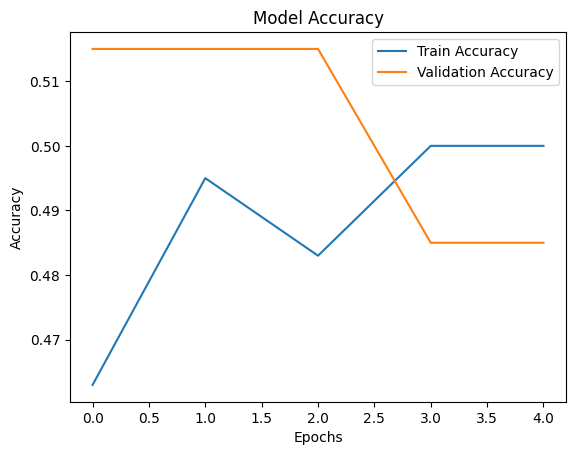

In [3]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt

num_samples = 1000
X_train = np.random.rand(num_samples, 96, 96, 3)
y_train = np.random.randint(0, 2, num_samples)
X_val = np.random.rand(num_samples // 5, 96, 96, 3)
y_val = np.random.randint(0, 2, num_samples // 5)

model = Sequential([
    Input(shape=(96, 96, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()





In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

## **Introduction to Colab and Python**

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

Welcome to this Colab where you will get a quick introduction to the Python programming language and the environment used for the course's exercises: Colab.

Colab is a Python development environment that runs in the browser using Google Cloud.

For example, to print "Hello World", just hover the mouse over [ ] and press the play button to the upper left. Or press shift-enter to execute.

In [ ]:
print("Hello World")

## Functions, Conditionals, and Iteration
Let's create a Python function, and call it from a loop.

In [ ]:
def HelloWorldXY(x, y):
  if (x < 10):
    print("Hello World, x was < 10")
  elif (x < 20):
    print("Hello World, x was >= 10 but < 20")
  else:
    print("Hello World, x was >= 20")
  return x + y

for i in range(8, 25, 5):  # i=8, 13, 18, 23 (start, stop, step)
  print("--- Now running with i: {}".format(i))
  r = HelloWorldXY(i,i)
  print("Result from HelloWorld: {}".format(r))

In [ ]:
print(HelloWorldXY(1,2))

Easy, right?

If you want a loop starting at 0 to 2 (exclusive) you could do any of the following

In [ ]:
print("Iterate over the items. `range(2)` is like a list [0,1].")
for i in range(2):
  print(i)

print("Iterate over an actual list.")
for i in [0,1]:
  print(i)

print("While works")
i = 0
while i < 2:
  print(i)
  i += 1

In [ ]:
print("Python supports standard key words like continue and break")
while True:
  print("Entered while")
  break

## Numpy and lists
Python has lists built into the language.
However, we will use a library called numpy for this.
Numpy gives you lots of support functions that are useful when doing Machine Learning.

Here, you will also see an import statement. This statement makes the entire numpy package available and we can access those symbols using the abbreviated 'np' syntax.

In [ ]:
import numpy as np  # Make numpy available using np.

# Create a numpy array, and append an element
a = np.array(["Hello", "World"])
a = np.append(a, "!")
print("Current array: {}".format(a))
print("Printing each element")
for i in a:
  print(i)

print("\nPrinting each element and their index")
for i,e in enumerate(a):
  print("Index: {}, was: {}".format(i, e))

In [ ]:
print("\nShowing some basic math on arrays")
b = np.array([0,1,4,3,2])
print("Max: {}".format(np.max(b)))
print("Average: {}".format(np.average(b)))
print("Max index: {}".format(np.argmax(b)))

In [ ]:
print("\nYou can print the type of anything")
print("Type of b: {}, type of b[0]: {}".format(type(b), type(b[0])))

In [ ]:
print("\nUse numpy to create a [3,3] dimension array with random number")
c = np.random.rand(3, 3)
print(c)

In [ ]:
print("\nYou can print the dimensions of arrays")
print("Shape of a: {}".format(a.shape))
print("Shape of b: {}".format(b.shape))
print("Shape of c: {}".format(c.shape))
print("...Observe, Python uses both [0,1,2] and (0,1,2) to specify lists")

## Colab Specifics

Colab is a virtual machine you can access directly. To run commands at the VM's terminal, prefix the line with an exclamation point (!).


In [ ]:
print("\nDoing $ls on filesystem")
!ls -l
!pwd

In [ ]:
print("Install numpy")  # Just for test, numpy is actually preinstalled in all Colab instances
!pip install numpy

**Exercise**

Create a code cell underneath this text cell and add code to:


*   List the path of the current directory (pwd)
* Go to / (cd) and list the content (ls -l)

In [ ]:
!pwd
!cd /
!ls -l
print("Hello")

All usage of Colab in this course is completely free or charge. Even GPU usage is provided free of charge for some hours of usage every day.

**Using GPUs**
* Many of the exercises in the course executes more quickly by using GPU runtime: Runtime | Change runtime type | Hardware accelerator | GPU

**Some final words on Colab**
*   You execute each cell in order, you can edit & re-execute cells if you want
*   Sometimes, this could have unintended consequences. For example, if you add a dimension to an array and execute the cell multiple times, then the cells after may not work. If you encounter problem reset your environment:
  *   Runtime -> Restart runtime... Resets your Python shell
  *   Runtime -> Restart all runtimes... Will reset the Colab image, and get you back to a 100% clean environment
* You can also clear the output in the Colab by doing: Edit -> Clear all outputs
* Colabs in this course are loaded from GitHub. Save to your Google Drive if you want a copy with your code/output: File -> Save a copy in Drive...

**Learn More**
*   Check out [this](https://www.youtube.com/watch?v=inN8seMm7UI&list=PLQY2H8rRoyvwLbzbnKJ59NkZvQAW9wLbx&index=3) episode of #CodingTensorFlow, and don't forget to subscribe to the YouTube channel ;)
